In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import pandas as pd


In [ ]:
data = pd.read_csv("C:/Users/MSIS/Downloads/AML/MLLabprojects/data/Salary_Data.csv")

In [ ]:
data

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [ ]:
x = data[["YearsExperience"]]
y = data["Salary"]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[9449.96]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.579e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
y_pred = model.predict(x_test)

In [ ]:
print("Actual values:", y_test.values)
print("predicted values:", y_pred)

Actual values: [112635.  67938. 113812.  83088.  64445.  57189.]
predicted values: [116511.83848464  72097.0155738  103281.8912346   75877.00050238
  56032.07962732  60757.06078805]


In [ ]:
print("Intercept:", model.intercept_)
print("Coefficient", model.coef_[0])

Intercept: 25792.20019866871
Coefficient 9449.962321455074


In [ ]:
new = pd.DataFrame({
    "YearsExperience": [18.5]
})

In [ ]:
predection = model.predict(new)
print("Predected:",predection[0])

Predected: 200616.50314558757


In [ ]:
print("MAE:", mean_absolute_error(y_test,y_pred))
print("MSE:", mean_squared_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))
print("R-squared:", r2_score(y_test,y_pred))

MAE: 6292.99058036377
MSE: 46452879.75484803
RMSE: 6815.634948766551
R-squared: 0.9090578530656058


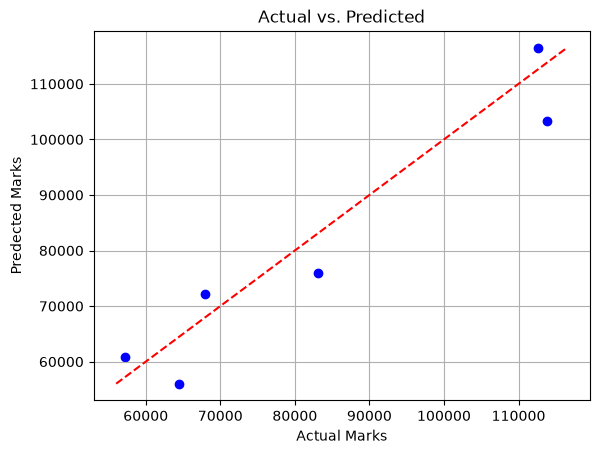

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, color="blue")

minimum = min(y_test.min(), y_pred.min())
maximum = max(y_test.max(), y_pred.max())

plt.plot(
    [minimum,maximum],
    [minimum,maximum],
    color="red",
    linestyle = "--"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predected Marks")
plt.title("Actual vs. Predicted")
plt.grid(True)
plt.show()


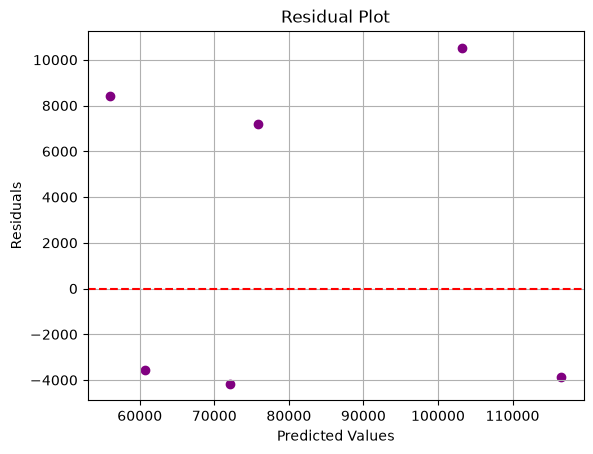

In [ ]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals, color="purple")
plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()


Using K-FOLD instead of train_test_split

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Tree Depth Comparison:
   Tree Depth  Mean R2 Score      Mean MSE     Mean RMSE
0         1.0       0.672176  1.701151e+08  13042.818093
1         2.0       0.864509  6.885002e+07   8297.590952
2         3.0       0.885137  5.156402e+07   7180.808860
3         4.0       0.898057  4.373801e+07   6613.471907
4         5.0       0.882265  4.852801e+07   6966.205122
5         NaN       0.877872  5.102449e+07   7143.142913

Best Tree Depth: 4

Final Model Performance:
MAE: 1553.9444444444441
RMSE: 2240.080022132146
R2 Score: 0.993092961314808


c:\Users\MSIS\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


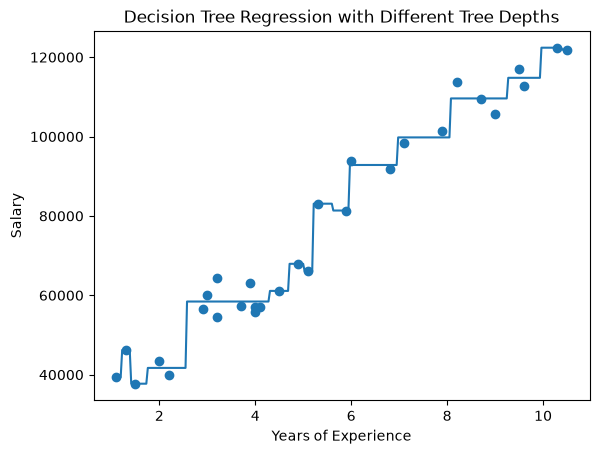

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the dataset
data = pd.read_csv("C:/Users/MSIS/Downloads/AML/MLLabprojects/data/Salary_Data.csv")

# Display the data
print(data.head())

# Select input and target
X = data[["YearsExperience"]]
y = data["Salary"]

# K-Fold Cross Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Different tree depths to compare
depths = [1, 2, 3, 4, 5, None]

results = []

for depth in depths:

    # Create Decision Tree Regressor
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )

    # R2 scores using K-Fold
    scores = cross_val_score(
        model,
        X,
        y,
        cv=kfold,
        scoring="r2"
    )

    # MSE scores using K-Fold
    mse_scores = -cross_val_score(
        model,
        X,
        y,
        cv=kfold,
        scoring="neg_mean_squared_error"
    )

    # Calculate average scores
    mean_r2 = scores.mean()
    mean_mse = mse_scores.mean()
    mean_rmse = np.sqrt(mean_mse)

    results.append([
        depth,
        mean_r2,
        mean_mse,
        mean_rmse
    ])

# Create results table
results_df = pd.DataFrame(
    results,
    columns=[
        "Tree Depth",
        "Mean R2 Score",
        "Mean MSE",
        "Mean RMSE"
    ]
)

print("\nTree Depth Comparison:")
print(results_df)

# Find best depth based on R2 score
best_depth = results_df.loc[
    results_df["Mean R2 Score"].idxmax(),
    "Tree Depth"
]

# Convert NumPy integer/float to Python integer
if pd.notna(best_depth):
    best_depth = int(best_depth)

print("\nBest Tree Depth:", best_depth)

# Create final model
final_model = DecisionTreeRegressor(
    max_depth=best_depth,
    random_state=42
)

# Train final model
final_model.fit(X, y)

# Predictions
y_pred = final_model.predict(X)

# Final model evaluation
print("\nFinal Model Performance:")
print("MAE:", mean_absolute_error(y, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred)))
print("R2 Score:", r2_score(y, y_pred))

# Plot actual data and predictions
X_plot = np.linspace(
    X["YearsExperience"].min(),
    X["YearsExperience"].max(),
    300
).reshape(-1, 1)

y_plot = final_model.predict(X_plot)

plt.scatter(X, y)
plt.plot(X_plot, y_plot)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Decision Tree Regression with Different Tree Depths")
plt.show()